# Preprocesamiento — Punto 3
**Taller 1 · Consultoría Económica con IA** | David Rodríguez · Juan Rueda · 2026

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

URL = (
    "https://raw.githubusercontent.com/darc-17/Sandbox_HE2_DavidRodriguez/"
    "main/Taller%201/Punto%203.%20Segmentacion%20de%20Clientes%20para%20"
    "Estrategia%20Comercial/segmentacion.csv"
)

df = pd.read_csv(URL)
print(f"Shape: {df.shape[0]:,} clientes × {df.shape[1]} variables")
print(f"Variables: {list(df.columns)}")

Shape: 1,000 clientes × 9 variables
Variables: ['id', 'age', 'gender', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'preferred_category', 'last_purchase_amount']


# Duplicados y missings

In [126]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"\nVariables con missings: {df.isna().sum().sum()}")
# Dataset completamente limpio: 0 duplicados, 0 missings

Filas duplicadas: 0

Variables con missings: 0


# Distribución de variables numéricas

In [127]:
# Todas presentan sesgo prácticamente nulo (< |0.10|), distribución uniforme.
# No se requieren transformaciones logarítmicas (a diferencia del Punto 2).
num_cols = ['age', 'income', 'spending_score', 'membership_years',
            'purchase_frequency', 'last_purchase_amount']

print("Estadísticos descriptivos:")
print(df[num_cols].describe().round(1).to_string())

print("\nAsimetría por variable:")
for col in num_cols:
    print(f"  {col:<25} skew = {df[col].skew():+.3f}")

Estadísticos descriptivos:
          age    income  spending_score  membership_years  purchase_frequency  last_purchase_amount
count  1000.0    1000.0          1000.0            1000.0              1000.0                1000.0
mean     43.8   88500.8            50.7               5.5                26.6                 492.3
std      15.0   34230.8            29.0               2.9                14.2                 295.7
min      18.0   30004.0             1.0               1.0                 1.0                  10.4
25%      30.0   57911.8            26.0               3.0                15.0                 218.8
50%      45.0   87845.5            50.0               5.0                27.0                 491.6
75%      57.0  116110.2            76.0               8.0                39.0                 747.2
max      69.0  149973.0           100.0              10.0                50.0                 999.7

Asimetría por variable:
  age                       skew = -0.046
  inco

# Distribución de variables categóricas

In [128]:
# Ambas categorías están balanceadas — no hay sesgo de representación.
print("Distribución gender:")
print(df['gender'].value_counts(normalize=True).mul(100).round(1).to_string())

print("\nDistribución preferred_category:")
print(df['preferred_category'].value_counts(normalize=True).mul(100).round(1).to_string())

Distribución gender:
gender
Male      35.7
Other     32.7
Female    31.6

Distribución preferred_category:
preferred_category
Electronics      21.5
Sports           21.0
Home & Garden    20.6
Groceries        19.9
Clothing         17.0


# Correlación entre variables numéricas

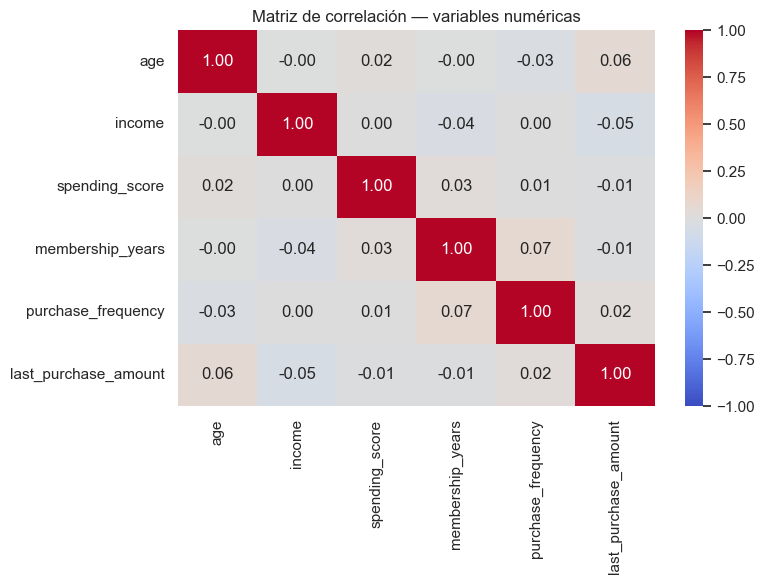

In [129]:
# Hallazgo clave: todas las correlaciones son cercanas a 0 (máximo |r| = 0.07).
# Las variables son prácticamente independientes entre sí — ningún predictor
# domina sobre otro, lo que favorece la segmentación multidimensional.
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación — variables numéricas")
plt.tight_layout()
plt.savefig("correlacion_segmentacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Outliers

In [130]:
# Resultado: 0 outliers en todas las variables. No se requiere tratamiento.
print("Outliers por variable (IQR 1.5×):")
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f"  {col:<25} {n_out} outliers")

Outliers por variable (IQR 1.5×):
  age                       0 outliers
  income                    0 outliers
  spending_score            0 outliers
  membership_years          0 outliers
  purchase_frequency        0 outliers
  last_purchase_amount      0 outliers


# Variables categóricas — almacenamiento para análisis post-clustering

In [131]:
# gender y preferred_category se reservan como metadatos para el análisis
# post-clustering (distribución por segmento), tal como Channel y Region
# en el notebook de referencia. No se incluyen en el clustering porque:
#   1. Su distribución es uniforme — no aportan separación entre grupos.
#   2. El one-hot encoding distorsiona la distancia euclidiana.

cat_meta = df[["gender", "preferred_category"]].copy()

print("Variables categóricas reservadas para análisis post-clustering:")
print(cat_meta.dtypes.to_string())
print(f"\nShape: {cat_meta.shape}")

Variables categóricas reservadas para análisis post-clustering:
gender                str
preferred_category    str

Shape: (1000, 2)


In [132]:
# ── Escalado de variables numéricas ──────────────────────────────────────────
# Se excluyen gender y preferred_category del clustering (reservadas en cat_meta).
# StandardScaler normaliza las 6 variables a media 0 y desviación 1.

NUM_COLS = ['age', 'income', 'spending_score',
            'membership_years', 'purchase_frequency', 'last_purchase_amount']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[NUM_COLS].values)

# Análisis de Componentes Principales (PCA)

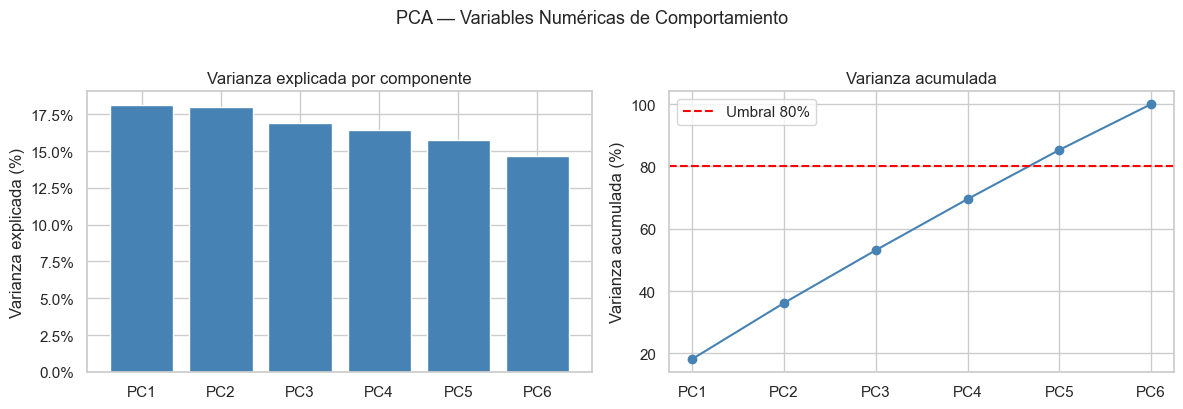

PC1: 18.16%  |  Acumulada: 18.16%
PC2: 18.01%  |  Acumulada: 36.16%
PC3: 16.94%  |  Acumulada: 53.11%
PC4: 16.41%  |  Acumulada: 69.51%
PC5: 15.78%  |  Acumulada: 85.30%
PC6: 14.70%  |  Acumulada: 100.00%


In [133]:
from sklearn.decomposition import PCA
import matplotlib.ticker as mticker

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

var_exp = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_exp)
comp_labels = [f"PC{i+1}" for i in range(len(var_exp))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comp_labels, var_exp * 100, color="steelblue", edgecolor="white")
axes[0].set_title("Varianza explicada por componente")
axes[0].set_ylabel("Varianza explicada (%)")
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

axes[1].plot(comp_labels, cum_var * 100, marker="o", color="steelblue")
axes[1].axhline(80, color="red", linestyle="--", label="Umbral 80%")
axes[1].set_title("Varianza acumulada")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].legend()

plt.suptitle("PCA — Variables Numéricas de Comportamiento", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

for i, (v, c) in enumerate(zip(var_exp, cum_var)):
    print(f"PC{i+1}: {v*100:.2f}%  |  Acumulada: {c*100:.2f}%")

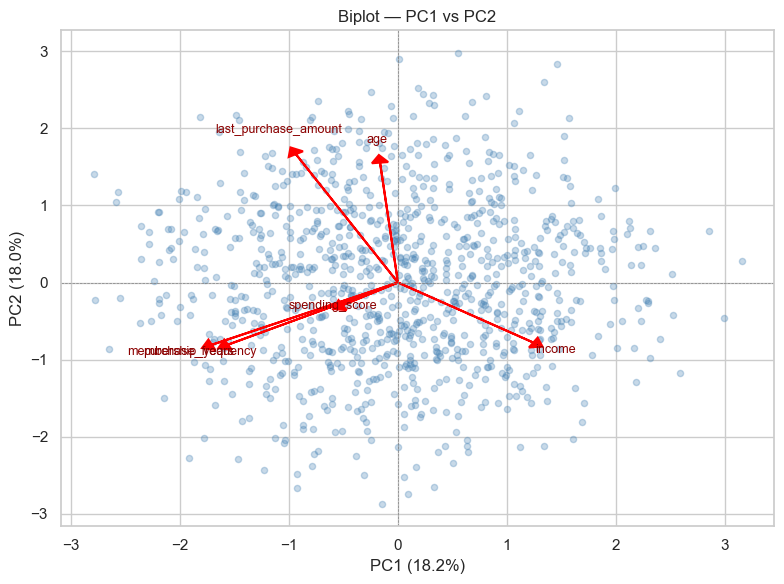

In [134]:
def biplot(score, coeff, labels, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.scatter(score[:, 0], score[:, 1], alpha=0.3, s=20, c="steelblue")
    scale = np.abs(score).max(axis=0)
    for i, label in enumerate(labels):
        ax.arrow(0, 0,
                 coeff[i, 0] * scale[0] * 0.9,
                 coeff[i, 1] * scale[1] * 0.9,
                 head_width=0.15, head_length=0.10,
                 fc="red", ec="red", linewidth=1.5)
        ax.text(coeff[i, 0] * scale[0] * 1.05,
                coeff[i, 1] * scale[1] * 1.05,
                label, fontsize=9, color="darkred", ha="center")
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title("Biplot — PC1 vs PC2")

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
biplot(X_pca, pca_2d.components_.T, NUM_COLS, ax=ax)
plt.tight_layout()
plt.show()

In [135]:
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=NUM_COLS,
    columns=["PC1", "PC2"]
).round(3)
print("Loadings (PC1 y PC2):")
print(loadings_df.sort_values("PC1", ascending=False).to_string())

Loadings (PC1 y PC2):
                        PC1    PC2
income                0.438 -0.290
age                  -0.058  0.580
spending_score       -0.179 -0.109
last_purchase_amount -0.330  0.621
purchase_frequency   -0.550 -0.301
membership_years     -0.602 -0.301


# K-Means

In [136]:
# ── Selección de k sobre espacio PCA ─────────────────────────────────────────
K_RANGE = range(2, 13)
results = []

for k in K_RANGE:
    km     = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    results.append({
        "k":         k,
        "inertia":   km.inertia_,
        "silhouette": silhouette_score(X_pca, labels, sample_size=500, random_state=RANDOM_STATE),
        "davies_bouldin": davies_bouldin_score(X_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
    })

res = pd.DataFrame(results)
print(res.round(4).to_string(index=False))

# ── K óptimo por Silhouette (mayor = mejor separación) ───────────────────────
k_opt = int(res.loc[res["silhouette"].idxmax(), "k"])
print(f"\nK óptimo (Silhouette máximo): k = {k_opt}"
      f"  →  sil = {res['silhouette'].max():.4f}"
      f"  |  db = {res.loc[res['silhouette'].idxmax(), 'davies_bouldin']:.4f}"
      f"  |  ch = {res.loc[res['silhouette'].idxmax(), 'calinski_harabasz']:.1f}")

 k   inertia  silhouette  davies_bouldin  calinski_harabasz
 2 1428.7551      0.3527          1.2266           517.6056
 3  936.7204      0.3659          0.9057           656.1869
 4  716.0880      0.3444          0.9044           673.9600
 5  600.3234      0.3352          0.8942           650.3063
 6  488.9877      0.3586          0.8156           683.3196
 7  426.5259      0.3337          0.8479           676.4022
 8  377.4460      0.3411          0.8374           672.9296
 9  336.9959      0.3310          0.8570           673.6938
10  302.3559      0.3356          0.8355           679.3750
11  278.1797      0.3419          0.8313           672.5424
12  258.2838      0.3300          0.8049           664.7111

K óptimo (Silhouette máximo): k = 3  →  sil = 0.3659  |  db = 0.9057  |  ch = 656.2


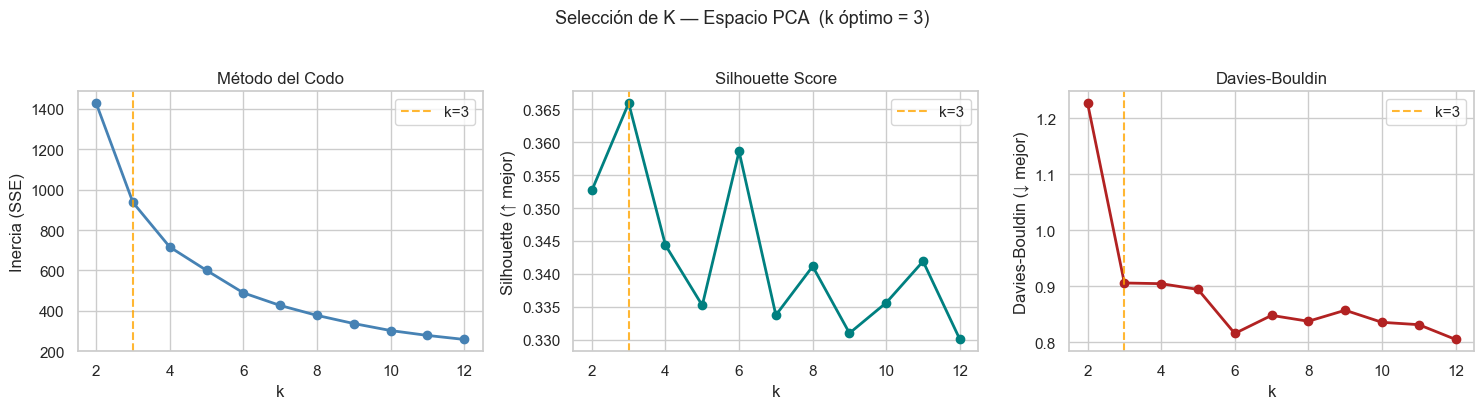

In [137]:
# ── Gráfico de selección de k ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(res["k"], res["inertia"], "o-", color="steelblue", linewidth=2)
axes[0].axvline(k_opt, color="orange", linestyle="--", alpha=0.8, label=f"k={k_opt}")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inercia (SSE)")
axes[0].set_title("Método del Codo"); axes[0].legend()

axes[1].plot(res["k"], res["silhouette"], "o-", color="teal", linewidth=2)
axes[1].axvline(k_opt, color="orange", linestyle="--", alpha=0.8, label=f"k={k_opt}")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette (↑ mejor)")
axes[1].set_title("Silhouette Score"); axes[1].legend()

axes[2].plot(res["k"], res["davies_bouldin"], "o-", color="firebrick", linewidth=2)
axes[2].axvline(k_opt, color="orange", linestyle="--", alpha=0.8, label=f"k={k_opt}")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin (↓ mejor)")
axes[2].set_title("Davies-Bouldin"); axes[2].legend()

plt.suptitle(f"Selección de K — Espacio PCA  (k óptimo = {k_opt})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("seleccion_k.png", dpi=150, bbox_inches="tight")
plt.show()

# Se elige k=3 como la estructura óptima en el espacio PCA porque:
#   - Método del Codo: El "quiebre" de la inercia (SSE) es más pronunciado en k=3, 
#     donde la ganancia de información empieza a disminuir linealmente.
#   - Silhouette Score: Presenta su máximo global absoluto en k=3 (~0.366), 
#     indicando la mejor cohesión interna y separación entre clusters.
#   - Davies-Bouldin: Muestra la caída más drástica precisamente en k=3, 
#     alcanzando un nivel de estabilidad (valores bajos son mejores).
#   - Consistencia: Las tres métricas convergen unánimemente en k=3, lo que otorga 
#     una robustez estadística superior para la segmentación posterior.

# Clustering Jerárquico

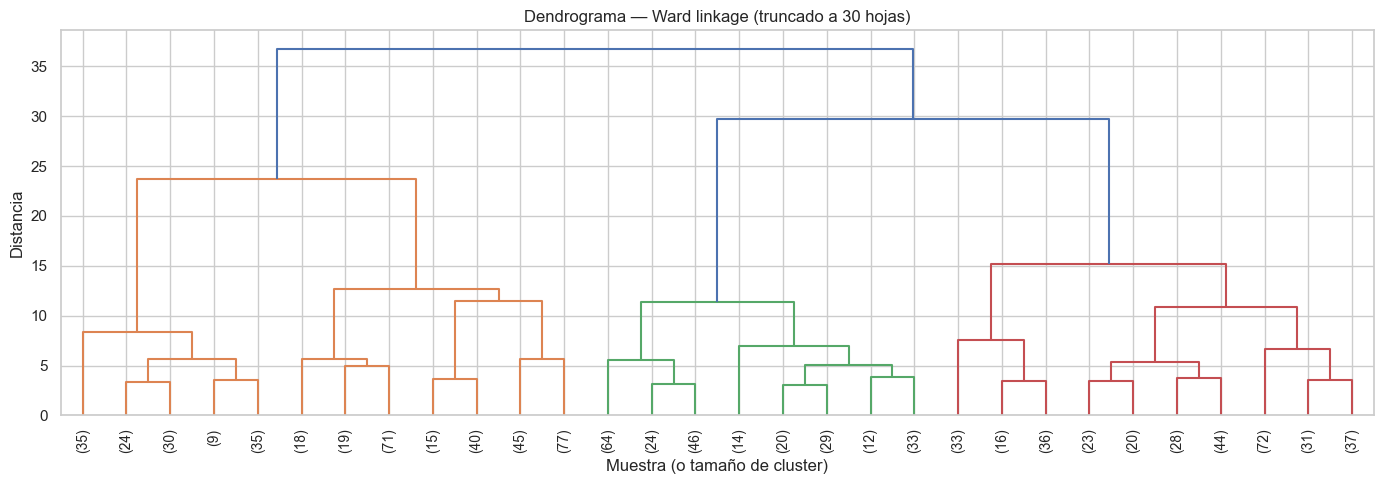

In [138]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_pca, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=10,
    ax=ax,
)
ax.set_title("Dendrograma — Ward linkage (truncado a 30 hojas)")
ax.set_xlabel("Muestra (o tamaño de cluster)")
ax.set_ylabel("Distancia")
plt.tight_layout()
plt.show()

K óptimo (Ward, Silhouette máximo): k = 3  →  sil = 0.3015


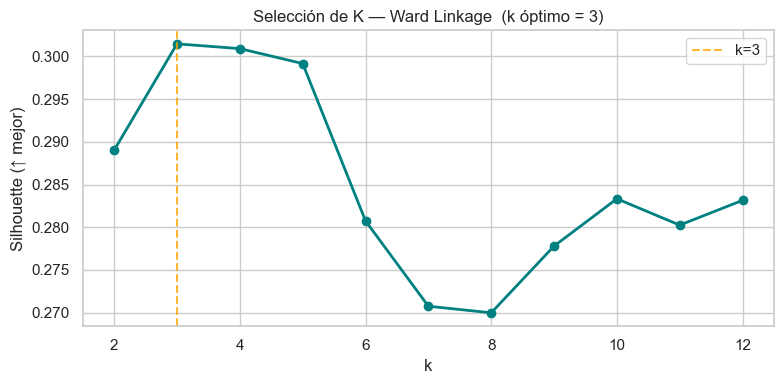

In [139]:
# ── Selección de k para Ward sobre espacio PCA ────────────────────────────────
sil_scores_ward = []

for k in K_RANGE:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels_k = agg.fit_predict(X_pca)
    sil_scores_ward.append(silhouette_score(X_pca, labels_k))

k_opt_ward = list(K_RANGE)[np.argmax(sil_scores_ward)]
print(f"K óptimo (Ward, Silhouette máximo): k = {k_opt_ward}"
      f"  →  sil = {max(sil_scores_ward):.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_RANGE), sil_scores_ward, "o-", color="teal", linewidth=2)
ax.axvline(k_opt_ward, color="orange", linestyle="--", alpha=0.8, label=f"k={k_opt_ward}")
ax.set_xlabel("k")
ax.set_ylabel("Silhouette (↑ mejor)")
ax.set_title(f"Selección de K — Ward Linkage  (k óptimo = {k_opt_ward})")
ax.legend()
plt.tight_layout()
plt.show()

Ward (k=3)  →  sil=0.3015  |  db=0.9942  |  ch=527.5


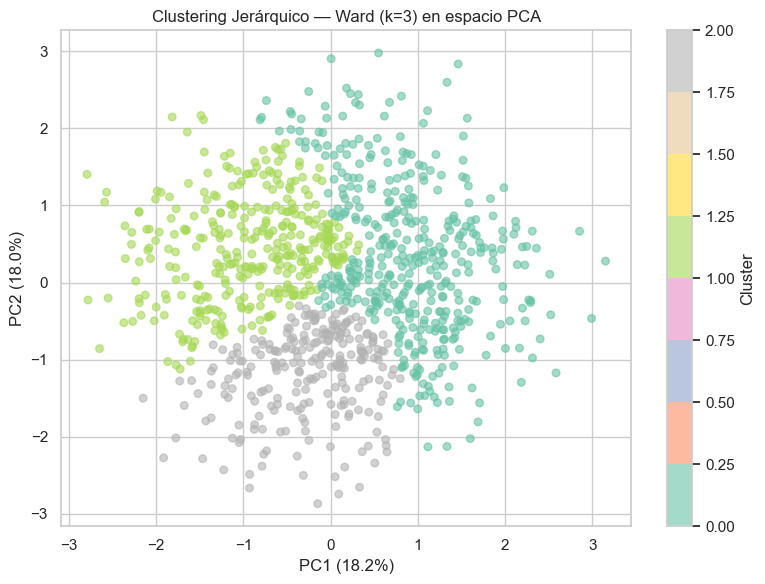

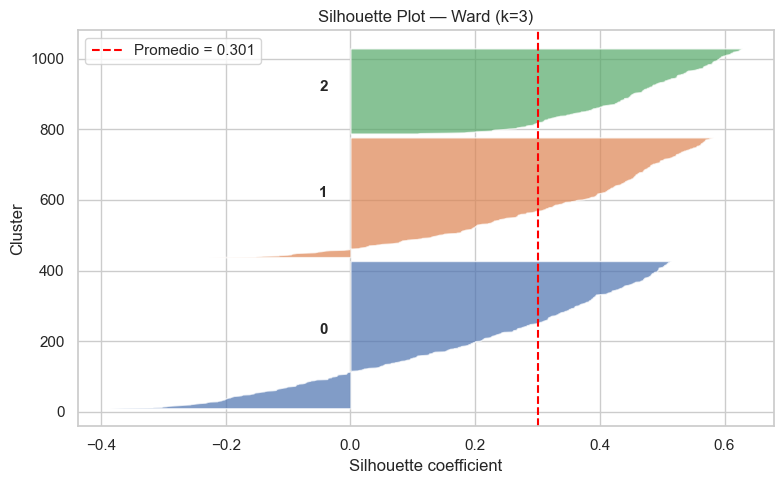

In [140]:
from sklearn.metrics import silhouette_samples

# ── Modelo final Ward ─────────────────────────────────────────────────────────
agg_final = AgglomerativeClustering(n_clusters=k_opt_ward, linkage="ward")
labels_ward = agg_final.fit_predict(X_pca)

sil_ward = silhouette_score(X_pca, labels_ward)
db_ward  = davies_bouldin_score(X_pca, labels_ward)
ch_ward  = calinski_harabasz_score(X_pca, labels_ward)
print(f"Ward (k={k_opt_ward})  →  sil={sil_ward:.4f}  |  db={db_ward:.4f}  |  ch={ch_ward:.1f}")

# ── Scatter en espacio PCA ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=labels_ward, cmap="Set2", alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
ax.set_title(f"Clustering Jerárquico — Ward (k={k_opt_ward}) en espacio PCA")
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

# ── Silhouette plot por cluster ───────────────────────────────────────────────
sil_avg  = silhouette_score(X_pca, labels_ward)
sil_vals = silhouette_samples(X_pca, labels_ward)

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in sorted(set(labels_ward)):
    cluster_sil = np.sort(sil_vals[labels_ward == i])
    y_upper = y_lower + cluster_sil.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_sil.shape[0], str(i),
            fontsize=11, fontweight="bold")
    y_lower = y_upper + 10
ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5,
           label=f"Promedio = {sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — Ward (k={k_opt_ward})")
ax.legend()
plt.tight_layout()
plt.show()

# DBSCAN

In [141]:
from sklearn.cluster import DBSCAN

# ── Grid search DBSCAN sobre espacio PCA ──────────────────────────────────────
eps_range         = np.arange(0.1, 2.1, 0.1)
min_samples_range = [3, 5, 7, 10]

dbscan_results = []

for eps in eps_range:
    for min_s in min_samples_range:
        db  = DBSCAN(eps=round(eps, 2), min_samples=min_s)
        lbl = db.fit_predict(X_pca)

        n_clusters = len(set(lbl) - {-1})
        n_noise    = (lbl == -1).sum()
        noise_pct  = round(n_noise / len(lbl) * 100, 1)

        mask = lbl != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = round(silhouette_score(X_pca[mask], lbl[mask]), 4)
        else:
            sil = np.nan

        dbscan_results.append({
            "eps":         round(eps, 2),
            "min_samples": min_s,
            "n_clusters":  n_clusters,
            "n_noise":     n_noise,
            "noise_pct":   noise_pct,
            "silhouette":  sil,
        })

df_dbscan = pd.DataFrame(dbscan_results)
print("Top 10 configuraciones por Silhouette:")
display(df_dbscan.dropna(subset=["silhouette"])
                 .sort_values("silhouette", ascending=False)
                 .head(10)
                 .reset_index(drop=True))

Top 10 configuraciones por Silhouette:


,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
0,0.1,10,2,976,97.6,0.6719
1,0.1,7,14,850,85.0,0.5926
2,0.1,5,46,597,59.7,0.4838
3,0.3,3,2,27,2.7,0.3068
4,0.1,3,79,337,33.7,0.2586
5,0.3,7,2,66,6.6,0.2392
6,0.3,5,2,50,5.0,0.2335
7,0.2,7,5,195,19.5,-0.0939
8,0.2,10,7,333,33.3,-0.1550
9,0.2,3,9,75,7.5,-0.1773


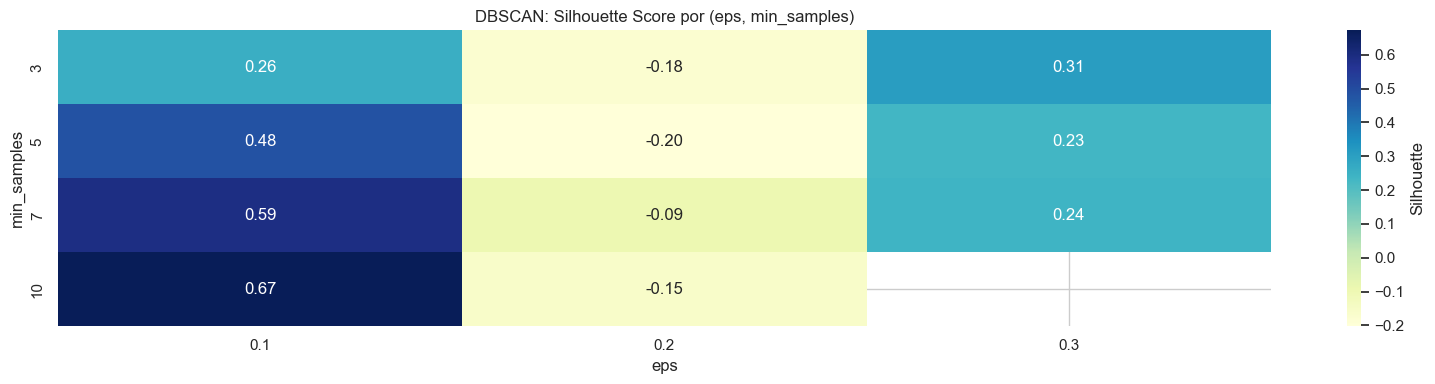

In [142]:
# ── Heatmap: Silhouette por (eps, min_samples) ────────────────────────────────
pivot = df_dbscan.pivot_table(index="min_samples", columns="eps", values="silhouette")

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu",
            ax=ax, cbar_kws={"label": "Silhouette"})
ax.set_title("DBSCAN: Silhouette Score por (eps, min_samples)")
ax.set_xlabel("eps")
ax.set_ylabel("min_samples")
plt.tight_layout()
plt.show()

Mejor DBSCAN: eps=0.3, min_samples=3
  Clusters: 2  |  Ruido: 2.7%  |  Silhouette: 0.3068

DBSCAN final  →  sil=0.3068  |  db=0.5450  |  ch=14.1  |  ruido=27 pts (2.7%)


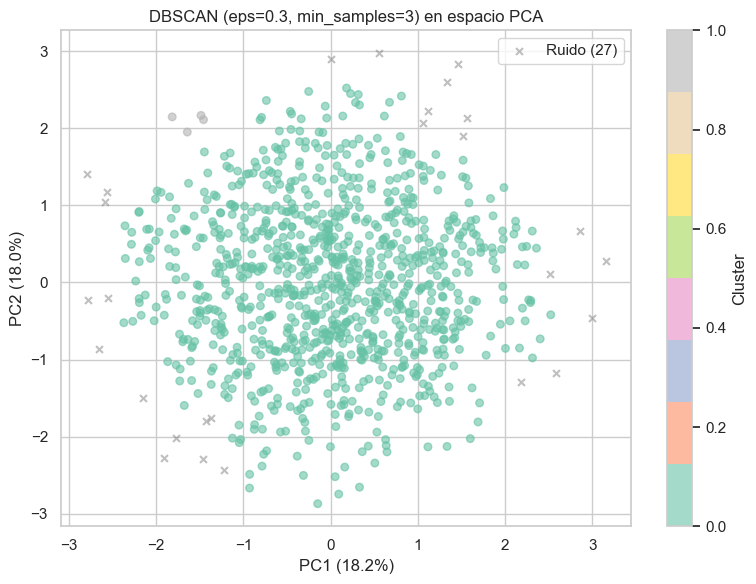

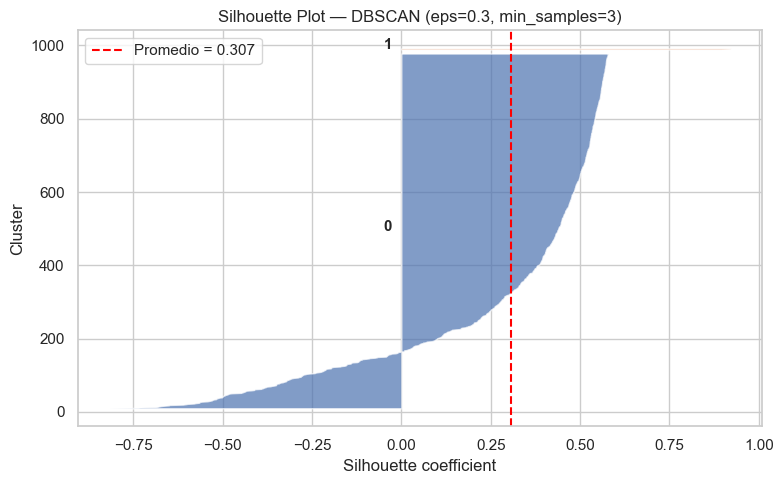

In [143]:
# ── Mejor configuración (Silhouette máximo, ruido < 30%) ─────────────────────
df_valid = (df_dbscan
            .dropna(subset=["silhouette"])
            .query("noise_pct < 30 and n_clusters >= 2"))

if len(df_valid) == 0:                      # fallback sin filtro de ruido
    df_valid = df_dbscan.dropna(subset=["silhouette"]).query("n_clusters >= 2")

best          = df_valid.sort_values("silhouette", ascending=False).iloc[0]
best_eps      = best["eps"]
best_min_samp = int(best["min_samples"])

print(f"Mejor DBSCAN: eps={best_eps}, min_samples={best_min_samp}")
print(f"  Clusters: {int(best['n_clusters'])}  |  Ruido: {best['noise_pct']}%"
      f"  |  Silhouette: {best['silhouette']:.4f}")

# ── Modelo final ──────────────────────────────────────────────────────────────
db_final  = DBSCAN(eps=best_eps, min_samples=best_min_samp)
labels_db = db_final.fit_predict(X_pca)

mask    = labels_db != -1
n_noise = (~mask).sum()
sil_db  = silhouette_score(X_pca[mask], labels_db[mask]) if mask.sum() > 1 else np.nan
db_db   = davies_bouldin_score(X_pca[mask], labels_db[mask]) if mask.sum() > 1 else np.nan
ch_db   = calinski_harabasz_score(X_pca[mask], labels_db[mask]) if mask.sum() > 1 else np.nan
print(f"\nDBSCAN final  →  sil={sil_db:.4f}  |  db={db_db:.4f}  |  ch={ch_db:.1f}"
      f"  |  ruido={n_noise} pts ({n_noise/len(labels_db)*100:.1f}%)")

# ── Scatter en espacio PCA ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors_plot = labels_db.astype(float)
colors_plot[labels_db == -1] = np.nan

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=colors_plot, cmap="Set2", alpha=0.6, s=30)
ax.scatter(X_pca[~mask, 0], X_pca[~mask, 1],
           c="grey", marker="x", alpha=0.5, s=25,
           label=f"Ruido ({n_noise})")
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
ax.set_title(f"DBSCAN (eps={best_eps}, min_samples={best_min_samp}) en espacio PCA")
ax.legend()
plt.colorbar(scatter, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

# ── Silhouette plot por cluster (excluye ruido) ───────────────────────────────
sil_vals     = silhouette_samples(X_pca[mask], labels_db[mask])
sil_avg      = sil_vals.mean()
labels_clean = labels_db[mask]

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in sorted(set(labels_clean)):
    cluster_sil = np.sort(sil_vals[labels_clean == i])
    y_upper = y_lower + cluster_sil.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * cluster_sil.shape[0], str(i),
            fontsize=11, fontweight="bold")
    y_lower = y_upper + 10
ax.axvline(x=sil_avg, color="red", linestyle="--", linewidth=1.5,
           label=f"Promedio = {sil_avg:.3f}")
ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Silhouette Plot — DBSCAN (eps={best_eps}, min_samples={best_min_samp})")
ax.legend()
plt.tight_layout()
plt.show()

# Comparación de Modelos

,modelo,n_clusters,n_noise,silhouette,davies_bouldin,calinski_harabasz
0,K-Means (k=3),3,0,0.3475,0.9057,656.2
1,"DBSCAN (eps=0.3, ms=3)",2,27,0.3068,0.5450,14.1
2,Ward (k=3),3,0,0.3015,0.9942,527.5


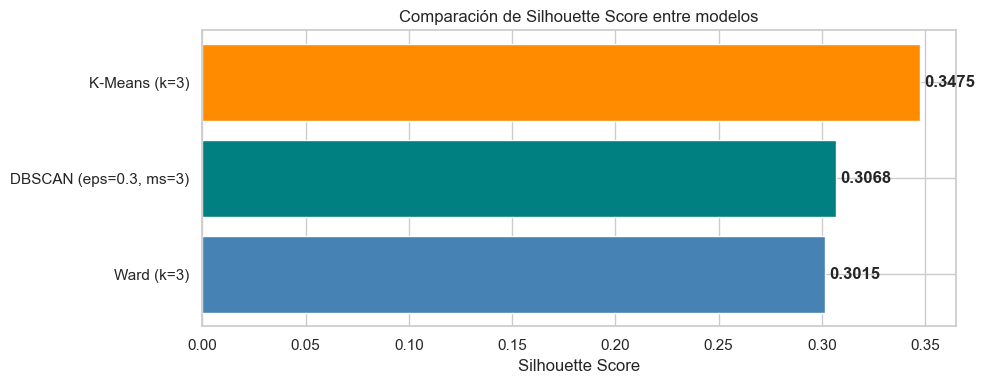

In [144]:
# ── Modelo final K-Means (para comparación) ───────────────────────────────────
km_final  = KMeans(n_clusters=k_opt, n_init=20, random_state=RANDOM_STATE)
labels_km = km_final.fit_predict(X_pca)
sil_km    = silhouette_score(X_pca, labels_km)
db_km     = davies_bouldin_score(X_pca, labels_km)
ch_km     = calinski_harabasz_score(X_pca, labels_km)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
mask_db = labels_db != -1

comp = pd.DataFrame([
    {
        "modelo":            f"K-Means (k={k_opt})",
        "n_clusters":         k_opt,
        "n_noise":            0,
        "silhouette":         round(sil_km, 4),
        "davies_bouldin":     round(db_km, 4),
        "calinski_harabasz":  round(ch_km, 1),
    },
    {
        "modelo":            f"Ward (k={k_opt_ward})",
        "n_clusters":         k_opt_ward,
        "n_noise":            0,
        "silhouette":         round(sil_ward, 4),
        "davies_bouldin":     round(db_ward, 4),
        "calinski_harabasz":  round(ch_ward, 1),
    },
    {
        "modelo":            f"DBSCAN (eps={best_eps}, ms={best_min_samp})",
        "n_clusters":         len(set(labels_db) - {-1}),
        "n_noise":            (~mask_db).sum(),
        "silhouette":         round(sil_db, 4),
        "davies_bouldin":     round(db_db, 4),
        "calinski_harabasz":  round(ch_db, 1),
    },
])

display(comp.sort_values("silhouette", ascending=False).reset_index(drop=True))

# ── Gráfico comparativo de Silhouette ─────────────────────────────────────────
comp_sorted = comp.sort_values("silhouette")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(comp_sorted["modelo"], comp_sorted["silhouette"],
               color=["steelblue", "teal", "darkorange"], edgecolor="white")
ax.set_xlabel("Silhouette Score")
ax.set_title("Comparación de Silhouette Score entre modelos")
for bar, val in zip(bars, comp_sorted["silhouette"]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

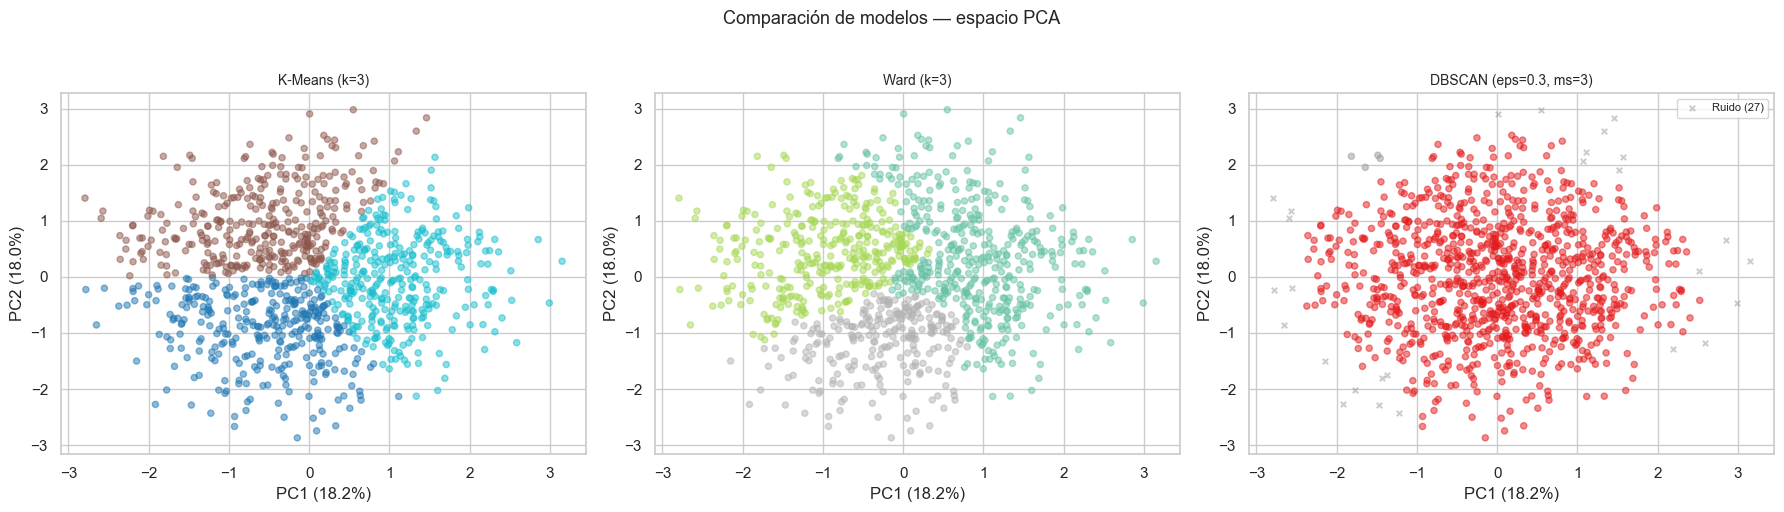


★  Mejor modelo por Silhouette: K-Means (k=3)
   sil=0.3475  |  db=0.9057  |  ch=656.2  |  clusters=3  |  ruido=0


In [145]:
# ── Scatter lado a lado: los 3 modelos en espacio PCA ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (labels_km,   f"K-Means (k={k_opt})",                       "tab10"),
    (labels_ward, f"Ward (k={k_opt_ward})",                      "Set2"),
    (labels_db,   f"DBSCAN (eps={best_eps}, ms={best_min_samp})", "Set1"),
]

for ax, (lbl, title, cmap) in zip(axes, configs):
    mask_noise = lbl == -1
    c = lbl.astype(float)
    c[mask_noise] = np.nan
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=c, cmap=cmap,
               alpha=0.5, s=20)
    if mask_noise.any():
        ax.scatter(X_pca[mask_noise, 0], X_pca[mask_noise, 1],
                   c="grey", marker="x", s=15, alpha=0.4,
                   label=f"Ruido ({mask_noise.sum()})")
        ax.legend(fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")

plt.suptitle("Comparación de modelos — espacio PCA", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Ganador ───────────────────────────────────────────────────────────────────
best_row   = comp.sort_values("silhouette", ascending=False).iloc[0]
best_model = best_row["modelo"]
print(f"\n★  Mejor modelo por Silhouette: {best_model}")
print(f"   sil={best_row['silhouette']:.4f}  |  db={best_row['davies_bouldin']:.4f}"
      f"  |  ch={best_row['calinski_harabasz']:.1f}"
      f"  |  clusters={int(best_row['n_clusters'])}  |  ruido={int(best_row['n_noise'])}")